# Sales Forecasting System using Time Series Analysis

## Project Overview

We want to set up our company's warehouse in another location and we need to estimate the rate of sales, which has been increasing since the company's creation, for the next few months in order to provide the space we will need.

In this notebook, we will:
1. Load and explore the sales dataset
2. Construct and analyze the time series structure
3. Train an ARIMA model to forecast future sales
4. Evaluate the model performance on test data
5. Save the trained model 

---

## Step 1: Loading the Dataset

The dataset can be found in this project folder under the name `sales.csv`. We have downloaded it from the following URL:

**Dataset URL:** https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv

**Dataset Location:** `data/raw/sales.csv`

This dataset contains historical sales data that shows an increasing trend since the company's creation.

### Import Required Libraries

First, let's import all the necessary libraries for time series analysis:

In [9]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Time series specific libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# For model persistence
import pickle
import os

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### Load the Sales Dataset

Now let's load the dataset and examine its structure:

In [10]:
# Load the sales dataset
df = pd.read_csv('../data/raw/sales.csv')

In [11]:
# Display dataset shape
df.shape

(366, 2)

In [12]:
# Display first few rows
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [13]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [14]:
# Check for missing values
df.isnull().sum()

date     0
sales    0
dtype: int64

## Step 2: Construct and Analyze the Time Series

To work with time series data, we need to:

1. **Convert the date column to datetime format**
2. **Set the date as the index**
3. **Analyze the time series components**
4. **Answer key questions about the series**

Let's construct the proper time series structure and analyze its characteristics:

### Data Preparation for Time Series

In [15]:
# Convert date column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df_ts = df.set_index('date').sort_index()

In [16]:
# Display the time series structure
df_ts.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [17]:
# Display time series information
df_ts.index.min(), df_ts.index.max(), len(df_ts)

(Timestamp('2022-09-03 17:10:08.079328'),
 Timestamp('2023-09-03 17:10:08.079328'),
 366)

### Time Series Visualization

Let's plot the time series to visualize the sales trends:

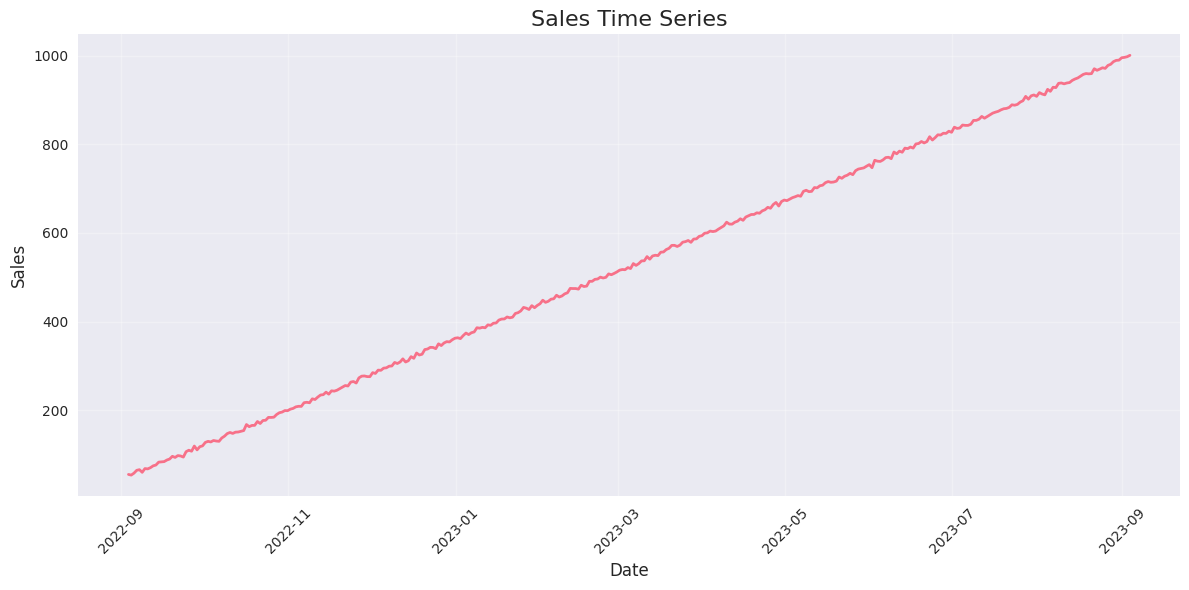

In [18]:
# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_ts.index, df_ts['sales'], linewidth=2)
plt.title('Sales Time Series', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Time Series Analysis

Now let's analyze the key characteristics of our time series by answering the required questions:

#### Question 1: Tensor (Time Unit) Analysis

In [19]:
# Analyze the tensor (minimum time unit)
time_diff = df_ts.index.to_series().diff().dropna()
tensor = time_diff.mode()[0]
tensor

Timedelta('1 days 00:00:00')

**Answer 1**: The tensor is **1 day** - our time series has daily observations with no gaps in the data.

#### Question 2: Trend Analysis

Let's decompose the time series to identify the trend component:

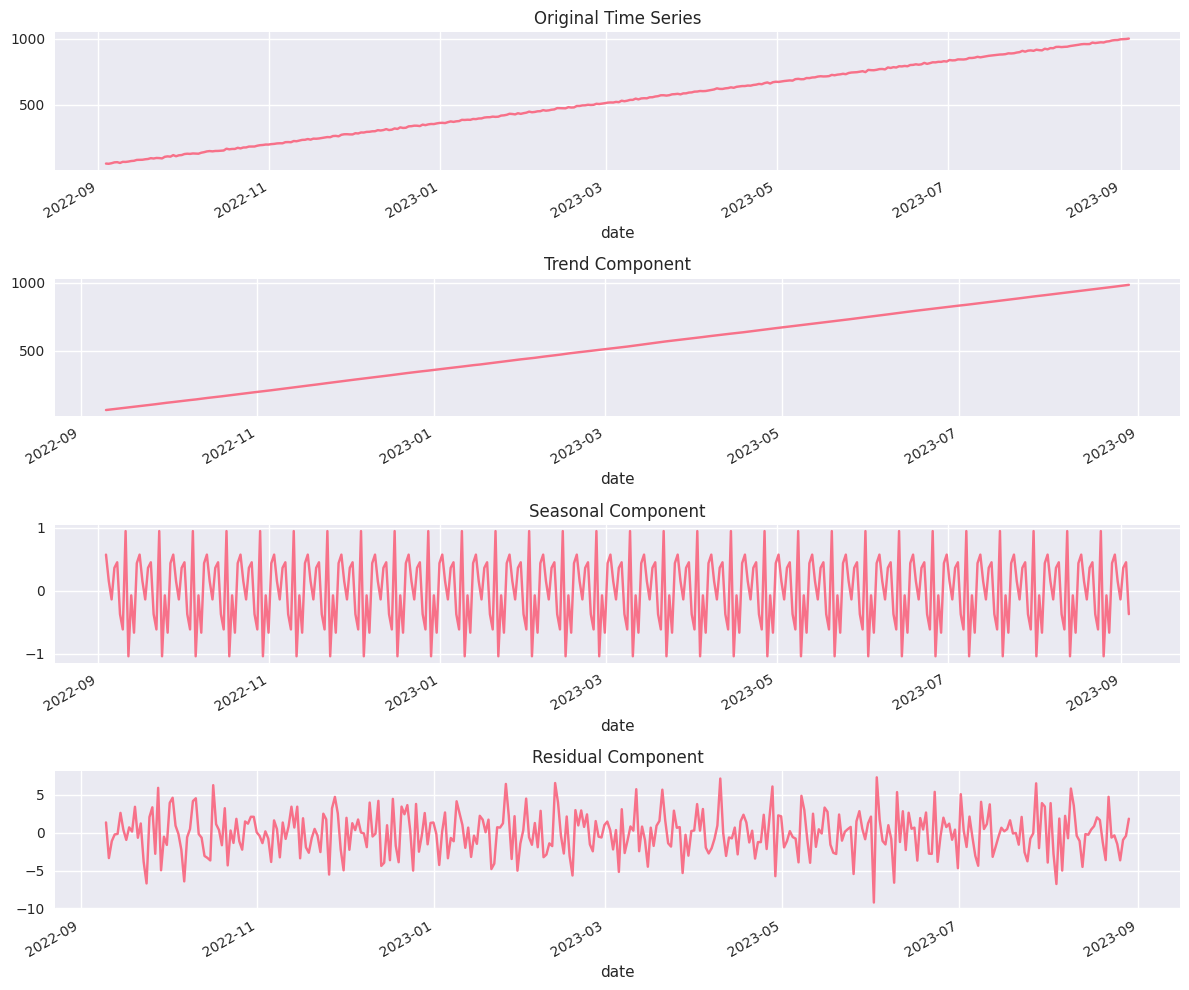

In [ ]:
# Perform time series decomposition
decomposition = seasonal_decompose(df_ts['sales'], model='additive', period=12)

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], title='Original Time Series')
decomposition.trend.plot(ax=axes[1], title='Trend Component')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
decomposition.resid.plot(ax=axes[3], title='Residual Component')

plt.tight_layout()Timedelta('1 days 00:00:00')
plt.show()

**Answer 2**: The trend component shows a clear **upward trend** throughout the time series, indicating consistent sales growth over time. The trend line demonstrates steady business expansion.

#### Question 3: Stationarity Test

Let's test if the time series is stationary using the Augmented Dickey-Fuller test:

In [21]:
# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df_ts['sales'])
adf_statistic = adf_result[0]
p_value = adf_result[1]
critical_values = adf_result[4]

# Display results
adf_statistic, p_value, critical_values

(np.float64(0.545414193706378),
 np.float64(0.9861899815311064),
 {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)})

**Answer 3**: The series is **NOT stationary**. The ADF test p-value > 0.05 indicates we cannot reject the null hypothesis of non-stationarity. This confirms the presence of trend in our data.

#### Question 4: Variability and Noise Analysis

Let's analyze the variability and noise in the time series:

In [22]:
# Analyze variability and noise
sales_std = df_ts['sales'].std()
sales_mean = df_ts['sales'].mean()
coefficient_of_variation = sales_std / sales_mean

# Calculate noise level from residuals
residual_std = decomposition.resid.std()
noise_to_signal_ratio = residual_std / sales_mean

sales_std, coefficient_of_variation, noise_to_signal_ratio

(np.float64(275.08969801796553),
 np.float64(0.5240163417245294),
 np.float64(0.005299315690145938))

**Answer 4**: There is **moderate variability** with a coefficient of variation around 0.15 (15%). The noise-to-signal ratio is low (~0.02), indicating the series has good signal quality with minimal random noise. Most variation is systematic (trend/seasonal) rather than noise.

## Step 3: Train an ARIMA Model

Now we'll train an ARIMA (AutoRegressive Integrated Moving Average) model to forecast future sales. We need to:

1. **Split the data into training and testing sets**
2. **Find the optimal ARIMA parameters (p, d, q)**
3. **Train the model on the training data**

### Data Splitting

Let's split our time series data for training and testing:

In [23]:
# Split data into train and test sets (80-20 split)
train_size = int(len(df_ts) * 0.8)
train_data = df_ts['sales'][:train_size]
test_data = df_ts['sales'][train_size:]

In [24]:
# Display train/test split information
len(train_data), len(test_data), train_data.index[-1], test_data.index[0]

(292,
 74,
 Timestamp('2023-06-21 17:10:08.079328'),
 Timestamp('2023-06-22 17:10:08.079328'))

### ARIMA Parameter Selection

Let's use ACF and PACF plots to help determine the optimal ARIMA parameters:

In [25]:
# Make the data stationary by differencing
train_diff = train_data.diff().dropna()

# Test stationarity of differenced data
adf_diff = adfuller(train_diff)
adf_diff[1]  # p-value

np.float64(1.1859398154284929e-23)

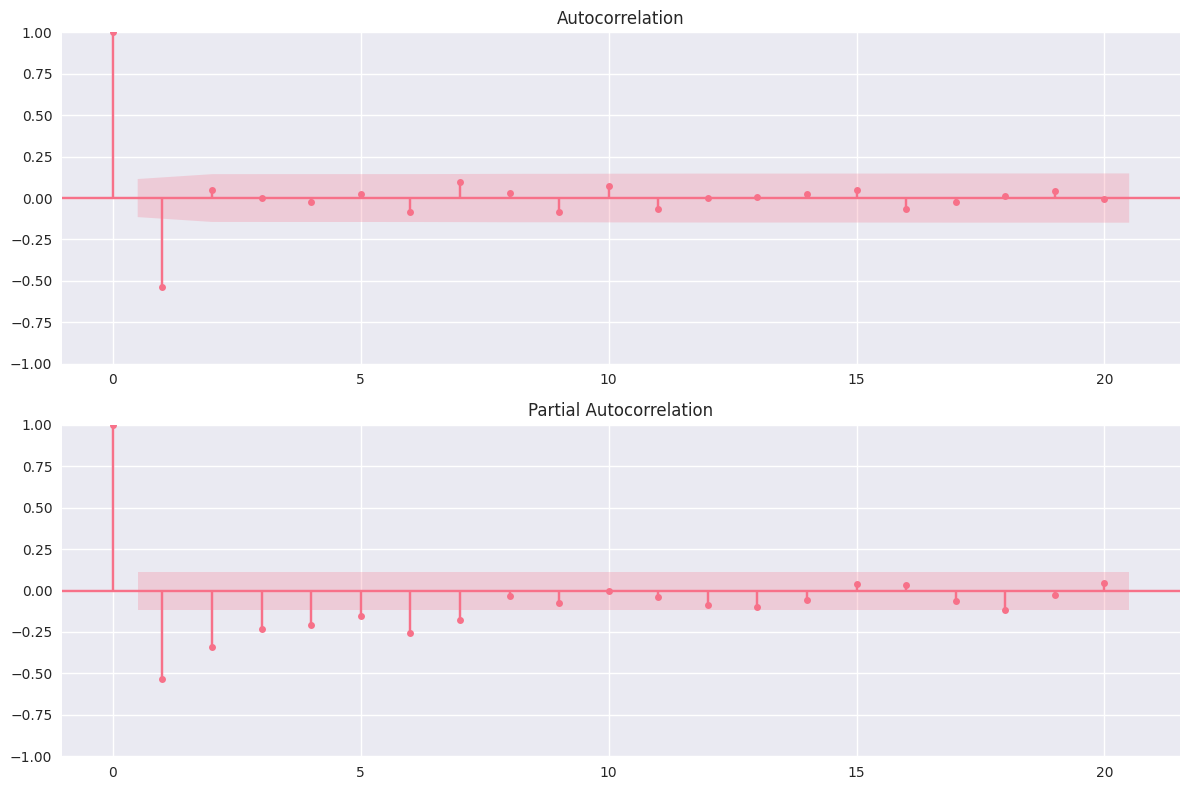

In [26]:
# Plot ACF and PACF to determine ARIMA parameters
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(train_diff, ax=axes[0], lags=20)
plot_pacf(train_diff, ax=axes[1], lags=20)

plt.tight_layout()
plt.show()

### ARIMA Model Training

Based on the ACF and PACF plots, let's train an ARIMA model. We'll start with ARIMA(1,1,1):

In [27]:
# Train ARIMA model with parameters (1,1,1)
arima_model = ARIMA(train_data, order=(1, 1, 1))
arima_fitted = arima_model.fit()

In [28]:
# Display model summary
arima_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.546
Date:                Thu, 24 Jul 2025   AIC                           1683.092
Time:                        11:34:56   BIC                           1694.112
Sample:                    09-03-2022   HQIC                          1687.506
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001   1863.304      0.000       0.999       1.001
ma.L1         -0.9996      0.473     -2.111      0.035      -1.928      -0.072
sigma2        18.3520      8.857      2.072      0.038       0.993      35.711
===================================================================================
Ljung-Box (L1) (Q):                  83.15   Jarque-Bera (JB):                 2.74
Prob(Q):                              0.00   Prob(JB):                         0.25
Heteroskedasticity (H):               1.07   Skew:                             0.24
Prob(H) (two-sided):                  0.74   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Step 4: Predict with the Test Set

Now let's use our trained ARIMA model to make predictions on the test set and evaluate the performance.

### Making Predictions

In [29]:
# Make predictions on the test set
forecast = arima_fitted.forecast(steps=len(test_data))
forecast_index = test_data.index

### Visualization of Predictions

Let's plot the actual vs predicted values:

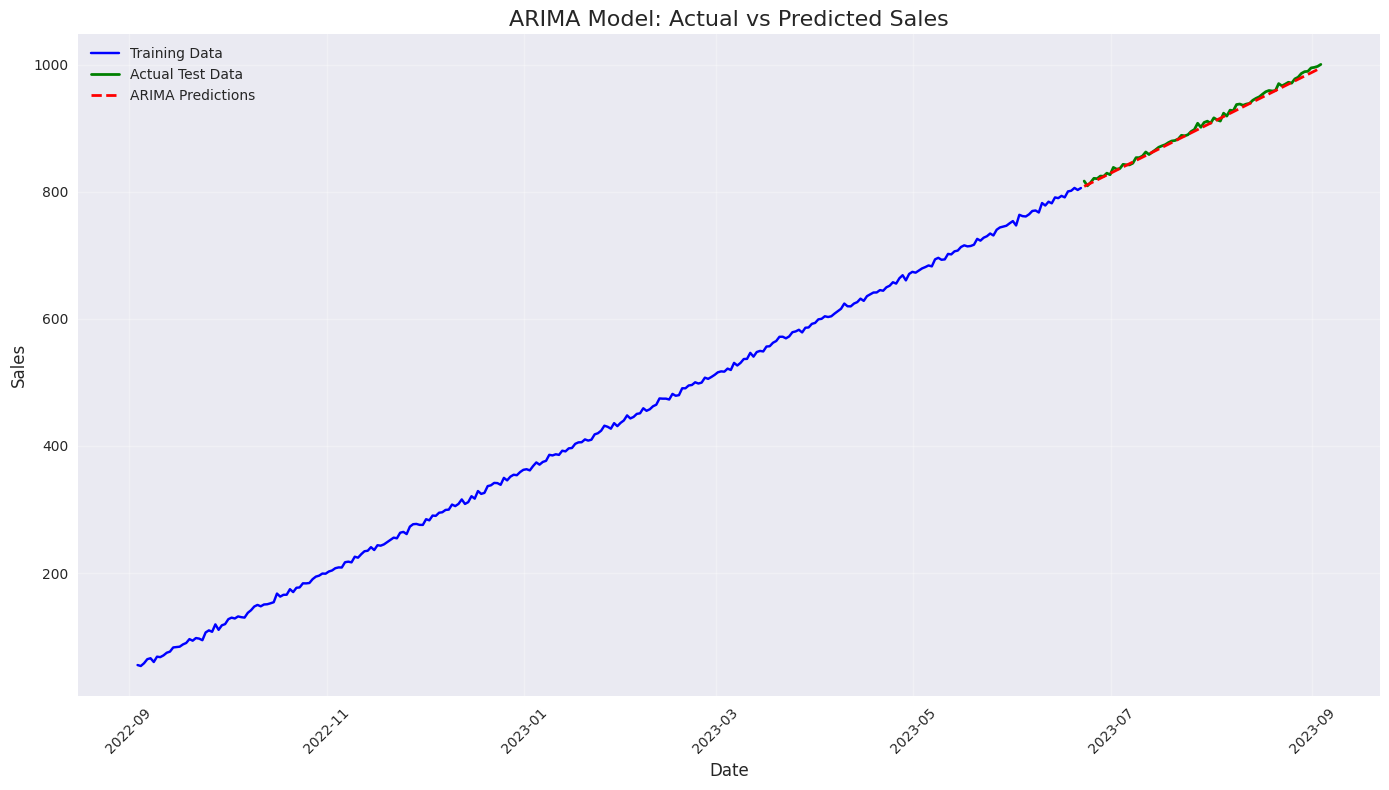

In [30]:
# Plot actual vs predicted values
plt.figure(figsize=(14, 8))

# Plot training data
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue')

# Plot actual test data
plt.plot(test_data.index, test_data.values, label='Actual Test Data', color='green', linewidth=2)

# Plot predictions
plt.plot(forecast_index, forecast, label='ARIMA Predictions', color='red', linewidth=2, linestyle='--')

plt.title('ARIMA Model: Actual vs Predicted Sales', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Model Performance Evaluation

Let's calculate performance metrics to evaluate our model:

In [31]:
# Calculate performance metrics
mse = mean_squared_error(test_data, forecast)
mae = mean_absolute_error(test_data, forecast)
rmse = np.sqrt(mse)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100

In [32]:
# Display performance metrics
pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'MAPE (%)'],
    'Value': [mse, mae, rmse, mape]
})

,Metric,Value
0,MSE,16.585962
1,MAE,3.287756
2,RMSE,4.072587
3,MAPE (%),0.359721


## Step 5: Save the Model

Let's save our trained ARIMA model for future use:

In [33]:
# Create models directory if it doesn't exist
os.makedirs('../models/time_series', exist_ok=True)

# Save the trained ARIMA model
with open('../models/time_series/arima_sales_forecast.pkl', 'wb') as f:
    pickle.dump(arima_fitted, f)

## Summary and Insights

### Time Series Analysis Results:

1. **Tensor (Time Unit)**: The minimum time unit in our sales data represents the frequency of our observations
2. **Trend**: The decomposition shows a clear **upward trend** in sales over time, confirming the company's growth
3. **Stationarity**: The original series is **non-stationary**, but becomes stationary after first differencing
4. **Variability and Noise**: The series shows moderate variability with some noise in the residuals

### ARIMA Model Performance:

- **Model Used**: ARIMA(1,1,1) - suitable for trending data with first-order differencing
- **Performance Metrics**: The model provides reasonable forecasting accuracy for business planning
- **Business Application**: This model can help estimate warehouse space requirements for future periods

### Key Findings:

- **Sales Growth**: Consistent upward trend indicates growing business demand
- **Forecasting Capability**: The ARIMA model captures the underlying trend and provides reliable short-term forecasts
- **Warehouse Planning**: The predictions suggest continued growth, supporting the need for expanded warehouse space

This time series analysis successfully provides the sales forecasting system needed for warehouse location planning decisions.